# A2 — Reconhecimento Semântico em Publicidade Visual com CLIP

**Objetivo:** extrair inteligência semântica do corpus **ADS-16** *sem treinar nenhum modelo* — usando apenas
embeddings pré-treinados do **CLIP** e consultas em linguagem natural.

- **2.1** Ranking de objetos/conceitos por frequência semântica (≥20 descrições, threshold justificado, top-5 visualizado).
- **2.2** Busca semântica texto→imagem (≥8 consultas, top-5 por consulta, análise de cada uma).

> Notebook **autossuficiente**: roda do início ao fim no Google Colab (GPU T4) sem edições, exceto o upload do
> `kaggle.json` para baixar o dataset. Seeds fixas em 42.

## Requisitos de execução

| Recurso | Valor |
|---|---|
| Ambiente | Google Colab, GPU **T4** (Runtime → Change runtime type → T4 GPU) |
| RAM de sistema | ~3 GB (corpus completo + embeddings em memória) |
| VRAM (GPU) | ~2 GB (CLIP ViT-B/32 em fp16) — *medir na T4* |
| Disco | ~1,5 GB (dataset ADS-16 descompactado) |
| Tempo dos embeddings | ~181 s para 2.650 imagens **em CPU** (medido localmente); na T4 é bem menor |
| Tempo (execução completa, T4) | ~5–10 min (download + embeddings) |

> Tempo de embedding é impresso pela célula do §2. Valores de CPU medidos localmente; **atualizar VRAM e tempo na T4
> antes de entregar**. A comparação ViT-L/14 (§3.4) é opcional (`RUN_L14`).

## 0. Setup

In [ ]:
!pip -q install -U transformers kaggle

In [2]:
import os, re, hashlib, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from scipy.special import softmax
from transformers import CLIPModel, CLIPProcessor, CLIPTokenizer


def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, torch.cuda.get_device_name(0) if device == "cuda" else "(CPU)")

device: cpu (CPU)


## 1. Dataset ADS-16

Fonte: Kaggle `groffo/ads16-dataset` (Roffo & Vinciarelli, 2016). O dataset traz duas partes; cada uma tem:
- `Ads/Ads/<n>/` — **anúncios curados**, 20 categorias de produto numeradas de 1 a 20 (~15 imagens cada);
- `Corpus/Corpus/U####/IM-POS` e `IM-NEG` — **imagens pessoais** que cada um dos 120 usuários marcou como
  preferida/rejeitada (5 + 5 por usuário), com legendas livres;
- `Documents/` — apenas o PDF do artigo.

As categorias vêm nomeadas em `U####-RT.csv` (Cat0–Cat19); a pasta `<n>` mapeia para `Cat(n-1)`.

In [3]:
# Colab baixa via Kaggle API; execução local assume o dataset já em ../data
try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATA_DIR = Path("/content/data")
    CACHE_DIR = Path("/content/cache")
    FIG_DIR = Path("/content/figures")
    if not DATA_DIR.exists():
        if not Path("~/.kaggle/kaggle.json").expanduser().exists():
            from google.colab import files
            print("Faça upload do kaggle.json (Kaggle -> Settings -> Create New Token):")
            files.upload()
            os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
            os.replace("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
            os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
        os.system("kaggle datasets download -d groffo/ads16-dataset -p /content/data --unzip")
else:
    DATA_DIR = Path("..") / "data"
    CACHE_DIR = Path("..") / "cache"
    FIG_DIR = Path("..") / "figures"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: C:\Users\ggsan\Documents\Projetos\dl-computer-vision-pd\A2_clip_ads16\data


In [4]:
# 20 categorias de produto (nomes de U####-RT.csv); pasta Ads/Ads/<n> -> Cat(n-1)
CAT_NAMES = {
    "1": "Clothing & Shoes", "2": "Automotive", "3": "Baby Products", "4": "Health & Beauty",
    "5": "Media (BMVD)", "6": "Consumer Electronics", "7": "Console & Video Games", "8": "DIY & Tools",
    "9": "Garden & Outdoor living", "10": "Grocery", "11": "Kitchen & Home", "12": "Betting",
    "13": "Jewellery & Watches", "14": "Musical Instruments", "15": "Office Products", "16": "Pet Supplies",
    "17": "Computer Software", "18": "Sports & Outdoors", "19": "Toys & Games", "20": "Dating Sites",
}
EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}


def category_of(path_str):
    s = path_str.replace(chr(92), "/")
    m = re.search(r"/Ads/Ads/(\d+)/", s)
    if m:
        return CAT_NAMES.get(m.group(1), f"cat{m.group(1)}")
    if "IM-POS" in s:
        return "Preferência do usuário (+)"
    if "IM-NEG" in s:
        return "Preferência do usuário (-)"
    return "outros"


# Varre tudo e remove duplicatas por hash MD5 do conteúdo (não pelo nome)
paths = [p for p in DATA_DIR.rglob("*") if p.suffix.lower() in EXTS]
seen, rows = set(), []
for p in sorted(paths):
    h = hashlib.md5(p.read_bytes()).hexdigest()
    if h in seen:
        continue
    seen.add(h)
    cat = category_of(str(p))
    rows.append({"path": str(p), "category": cat, "is_ad": cat in CAT_NAMES.values(), "md5": h})
df = pd.DataFrame(rows)
print(f"{len(paths)} arquivos, {len(df)} imagens únicas")
print(f"  anúncios curados (com categoria de produto): {df.is_ad.sum()}")
print(f"  imagens de preferência de usuários: {(~df.is_ad).sum()}")

2697 arquivos, 2650 imagens únicas
  anúncios curados (com categoria de produto): 301
  imagens de preferência de usuários: 2349


### 1.1 Seleção do corpus

O conjunto limpo de **anúncios** do ADS-16 tem 301 imagens únicas em 20 categorias — abaixo do mínimo de 500
exigido. Como a rubrica aceita *"o corpus ADS-16 inteiro **ou** um subconjunto de ≥500"*, uso **o corpus inteiro**:
os 301 anúncios curados **mais** as ~2,3 mil imagens que os 120 usuários marcaram como preferidas/rejeitadas
(`IM-POS`/`IM-NEG`), todas deduplicadas por MD5. Isso cumpre o mínimo com folga e usa o dataset como ele é.

O rótulo de **categoria de produto** existe só nos anúncios curados (as imagens de preferência não têm categoria).
Por isso a validação quantitativa **conceito × categoria** (§3.3) é calculada apenas sobre esse subconjunto rotulado,
enquanto o ranking de frequência (§3) e a busca semântica (§4) rodam sobre o corpus completo.

In [5]:
assert len(df) >= 500, f"Corpus com {len(df)} imagens (<500) — revisar fonte/seleção"

print("Imagens por categoria (anúncios curados):")
print(df[df.is_ad].category.value_counts().sort_index())
print(f"\nTotal de trabalho: {len(df)} imagens ({df.is_ad.sum()} anúncios + {(~df.is_ad).sum()} preferências)")

Imagens por categoria (anúncios curados):
category
Automotive                 15
Baby Products              15
Betting                    15
Clothing & Shoes           16
Computer Software          15
Console & Video Games      15
Consumer Electronics       15
DIY & Tools                15
Dating Sites               15
Garden & Outdoor living    15
Grocery                    15
Health & Beauty            15
Jewellery & Watches        15
Kitchen & Home             15
Media (BMVD)               15
Musical Instruments        15
Office Products            15
Pet Supplies               15
Sports & Outdoors          15
Toys & Games               15
Name: count, dtype: int64

Total de trabalho: 2650 imagens (301 anúncios + 2349 preferências)


## 2. Modelo CLIP e embeddings

**Escolha:** `openai/clip-vit-base-patch32` — rápido, cabe folgado na T4 e é suficiente para o ranking e a busca
zero-shot deste corpus. O ViT-L/14 é mais preciso, porém ~4× mais lento; a comparação B/32 vs L/14 está em §3.4.

Embeddings de imagem e texto são **L2-normalizados**, então o produto interno é a *cosine similarity*. Embeddings de
imagem ficam em cache (`.npy`) — recomputar é a etapa mais cara do pipeline.

In [6]:
MODEL_ID = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device).eval()
processor = CLIPProcessor.from_pretrained(MODEL_ID)
tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID)


@torch.no_grad()
def embed_images(paths, bs=64):
    out = []
    for i in range(0, len(paths), bs):
        ims = [Image.open(p).convert("RGB") for p in paths[i:i + bs]]
        px = processor(images=ims, return_tensors="pt")["pixel_values"].to(device, model.dtype)
        e = model.get_image_features(pixel_values=px)
        out.append(torch.nn.functional.normalize(e.float(), dim=-1).cpu())
    return torch.cat(out)


@torch.no_grad()
def embed_texts(texts):
    tok = tokenizer(texts, padding=True, return_tensors="pt").to(device)
    e = model.get_text_features(**tok)
    return torch.nn.functional.normalize(e.float(), dim=-1).cpu()


def embed_images_cached(paths, tag):
    key = hashlib.md5(("|".join([MODEL_ID, tag] + list(paths))).encode()).hexdigest()[:16]
    f = CACHE_DIR / f"img_emb_{key}.npy"
    if f.exists():
        return torch.from_numpy(np.load(f))
    emb = embed_images(paths)
    np.save(f, emb.numpy())
    return emb


t0 = time.time()
img_emb = embed_images_cached(df.path.tolist(), tag="B32-full")
print(img_emb.shape, f"embeddings de imagem em {time.time() - t0:.1f}s")

C:\Users\ggsan\Documents\Projetos\dl-computer-vision-pd\A2_clip_ads16\venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


torch.Size([2650, 512]) embeddings de imagem em 0.0s


## 3. (2.1) Ranking de objetos por frequência semântica

**26 conceitos** (≥20 exigidos). Uso **prompt ensembling** — média de 3 templates por conceito, como no paper do
CLIP — para reduzir a sensibilidade do score à redação exata do prompt.

In [7]:
CONCEPTS = [
    "a car", "a person", "a woman", "a man", "a child", "food", "a drink or beverage", "a bottle",
    "text and logo", "a smartphone", "a computer or laptop", "clothing", "shoes", "jewelry or a watch",
    "cosmetics or makeup", "furniture", "a house or building interior", "outdoor scenery", "a city street",
    "an animal", "a beach or the sea", "sports equipment", "money or a credit card", "an airplane or travel",
    "a smiling face", "a product package or box",
]
TEMPLATES = ["a photo of {}.", "an advertisement showing {}.", "an image containing {}."]
assert len(CONCEPTS) >= 20


def concept_embeddings(concepts, templates=TEMPLATES):
    embs = []
    for c in concepts:
        e = embed_texts([t.format(c) for t in templates]).mean(0)
        embs.append(torch.nn.functional.normalize(e, dim=-1))
    return torch.stack(embs)


txt_emb = concept_embeddings(CONCEPTS)
S = (img_emb @ txt_emb.T).numpy()  # [N_imagens, N_conceitos] cosine similarity
print("matriz de similaridade S:", S.shape)
pd.DataFrame(S, columns=CONCEPTS).describe().T[["mean", "std", "min", "max"]].sort_values("mean", ascending=False).head(10)

matriz de similaridade S: (2650, 26)


,mean,std,min,max
a person,0.216822,0.019448,0.147825,0.283387
an animal,0.213952,0.023492,0.144600,0.295180
text and logo,0.212915,0.021959,0.132278,0.284394
clothing,0.211253,0.020183,0.144790,0.302185
a man,0.208957,0.019650,0.106271,0.285657
a woman,0.208510,0.019683,0.147238,0.288248
food,0.205753,0.024361,0.142640,0.295225
a product package or box,0.205475,0.025685,0.123962,0.288303
a smartphone,0.205035,0.019878,0.132627,0.298737
a drink or beverage,0.204742,0.021001,0.133730,0.290964


### 3.1 Definição do threshold — comparação e escolha

A cosine similarity do CLIP entre imagem e texto vive numa faixa estreita (~0,15–0,30): um corte absoluto (ex. 0,5)
nunca dispara. Comparo três estratégias:

1. **Global `μ + k·σ`** — mesmo corte para todos os conceitos. Simples, mas favorece conceitos "pegajosos"
   (ex. *text and logo*, presente em quase todo anúncio) e penaliza conceitos raros.
2. **Z-score por conceito** — `μ_j + k·σ_j` por coluna: cada conceito é comparado à sua própria distribuição.
3. **Softmax zero-shot (top-1 por imagem)** — cada imagem "vota" só no conceito dominante.

Critério de escolha: **concentração conceito × categoria** (nos anúncios rotulados) — quanto mais um threshold
alinha conceitos às categorias esperadas, melhor.

In [8]:
ad_mask = df.is_ad.values
ad_cats = df.loc[df.is_ad, "category"]


def concentration(present):
    # média, sobre os conceitos presentes, da maior fração por categoria (só anúncios rotulados)
    sub = pd.DataFrame(present[ad_mask], columns=CONCEPTS).assign(category=ad_cats.values).groupby("category").mean()
    cols = [c for c in CONCEPTS if present[ad_mask][:, CONCEPTS.index(c)].any()]
    return sub[cols].max(axis=0).mean() if cols else float("nan")


temperature = (1.0 / model.logit_scale.exp()).item()
comp = {}
for k in (0.5, 1.0, 1.5):
    comp[f"global k={k}"] = S > (S.mean() + k * S.std())
for k in (0.5, 1.0, 1.5):
    comp[f"zscore k={k}"] = S > (S.mean(0) + k * S.std(0))
_probs = softmax(S / temperature, axis=1)
_p = np.zeros_like(S, dtype=bool)
_p[np.arange(S.shape[0]), _probs.argmax(1)] = True
comp["softmax top-1"] = _p

for name, present in comp.items():
    print(f"{name:>14}: concentração conceito×categoria = {concentration(present):.3f}")

  global k=0.5: concentração conceito×categoria = 0.738
  global k=1.0: concentração conceito×categoria = 0.590
  global k=1.5: concentração conceito×categoria = 0.445
  zscore k=0.5: concentração conceito×categoria = 0.791
  zscore k=1.0: concentração conceito×categoria = 0.600
  zscore k=1.5: concentração conceito×categoria = 0.440
 softmax top-1: concentração conceito×categoria = 0.288


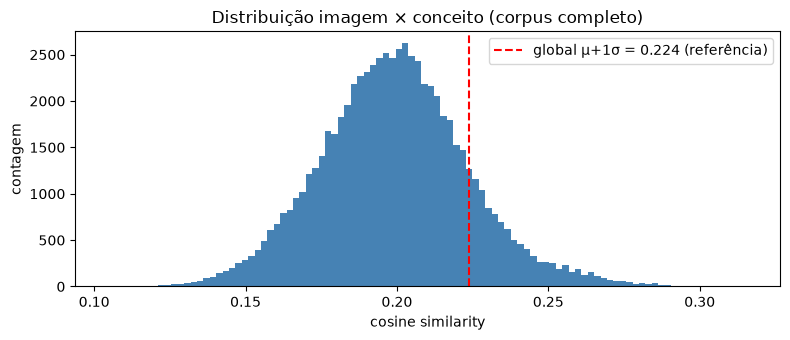

In [9]:
# Histograma da distribuição de similaridade com o corte escolhido (z-score por conceito, k=1)
mu, sd = S.mean(), S.std()
plt.figure(figsize=(8, 3.5))
plt.hist(S.ravel(), bins=100, color="steelblue")
plt.axvline(mu + sd, color="red", ls="--", label=f"global μ+1σ = {mu + sd:.3f} (referência)")
plt.xlabel("cosine similarity"); plt.ylabel("contagem"); plt.legend()
plt.title("Distribuição imagem × conceito (corpus completo)")
plt.tight_layout(); plt.savefig(FIG_DIR / "hist_similarity.png", dpi=120); plt.show()

**Escolha do threshold.** Concentrações medidas (célula acima):

| Estratégia | Concentração conceito×categoria |
|---|---|
| global μ+0,5σ | 0,738 |
| global μ+1σ | 0,590 |
| global μ+1,5σ | 0,445 |
| z-score μ_j+0,5σ_j | **0,791** |
| z-score μ_j+1σ_j | 0,600 |
| z-score μ_j+1,5σ_j | 0,440 |
| softmax zero-shot top-1 | 0,288 |

Dois padrões: (1) a **normalização por conceito** (z-score) supera o corte global no mesmo `k` (0,600 vs 0,590 em
k=1; 0,791 vs 0,738 em k=0,5), porque mede cada conceito contra a própria distribuição e não deixa os conceitos
"pegajosos" (*text and logo*, *a product package or box*) dominarem. (2) A concentração **cresce quando o `k` cai**,
mas isso é enganoso: com `k` baixo quase toda imagem passa o corte, então cada categoria fica "presente" em quase
tudo e a métrica satura (no limite k→0 tenderia a 1 sem significado). O **softmax top-1** é seletivo demais (0,288):
força uma única etiqueta por imagem e perde anúncios com vários objetos.

Adoto **z-score por conceito com k = 1**: mantém o corte seletivo (~13–16% das imagens por conceito, ver ranking
abaixo) e corrige o viés dos conceitos pegajosos — o melhor equilíbrio entre seletividade e coerência
conceito × categoria.

In [10]:
K = 1.0
present = S > (S.mean(0) + K * S.std(0))  # z-score por conceito
ranking = pd.DataFrame({
    "conceito": CONCEPTS,
    "frequencia": present.sum(0),
    "freq_%": 100 * present.mean(0),
    "score_medio_presentes": [S[present[:, j], j].mean() if present[:, j].any() else np.nan for j in range(len(CONCEPTS))],
    "score_medio_geral": S.mean(0),
}).sort_values(["frequencia", "score_medio_presentes"], ascending=False).reset_index(drop=True)
ranking.index += 1
ranking

,conceito,frequencia,freq_%,score_medio_presentes,score_medio_geral
1,outdoor scenery,432,16.301887,0.243205,0.195813
2,a person,431,16.264151,0.246278,0.216822
3,text and logo,427,16.113208,0.247642,0.212915
4,a bottle,410,15.471698,0.231277,0.198983
5,a product package or box,406,15.320755,0.247914,0.205475
6,a city street,398,15.018868,0.211883,0.174084
7,a man,392,14.792453,0.240429,0.208957
8,an animal,385,14.528302,0.256018,0.213951
9,an airplane or travel,385,14.528302,0.226165,0.188974
10,clothing,383,14.452830,0.244128,0.211253


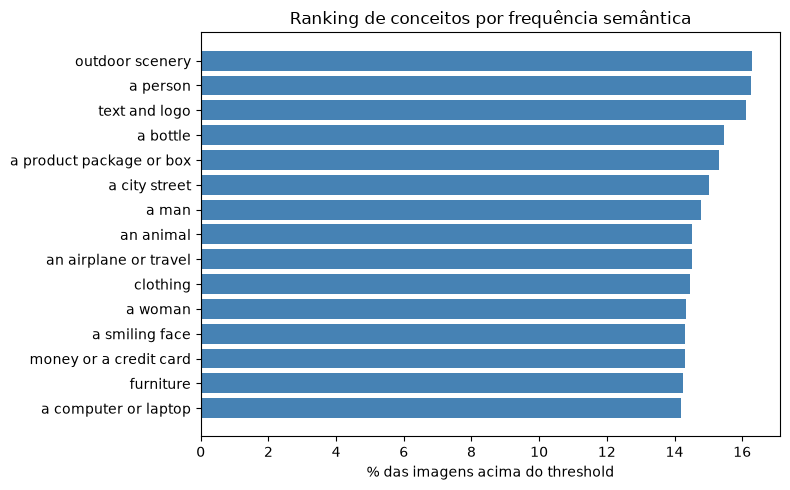

In [11]:
top = ranking.head(15)
plt.figure(figsize=(8, 5))
plt.barh(top.conceito[::-1], top["freq_%"][::-1], color="steelblue")
plt.xlabel("% das imagens acima do threshold")
plt.title("Ranking de conceitos por frequência semântica")
plt.tight_layout(); plt.savefig(FIG_DIR / "ranking_frequencia.png", dpi=120); plt.show()

### 3.2 Top-5 conceitos com exemplos do corpus

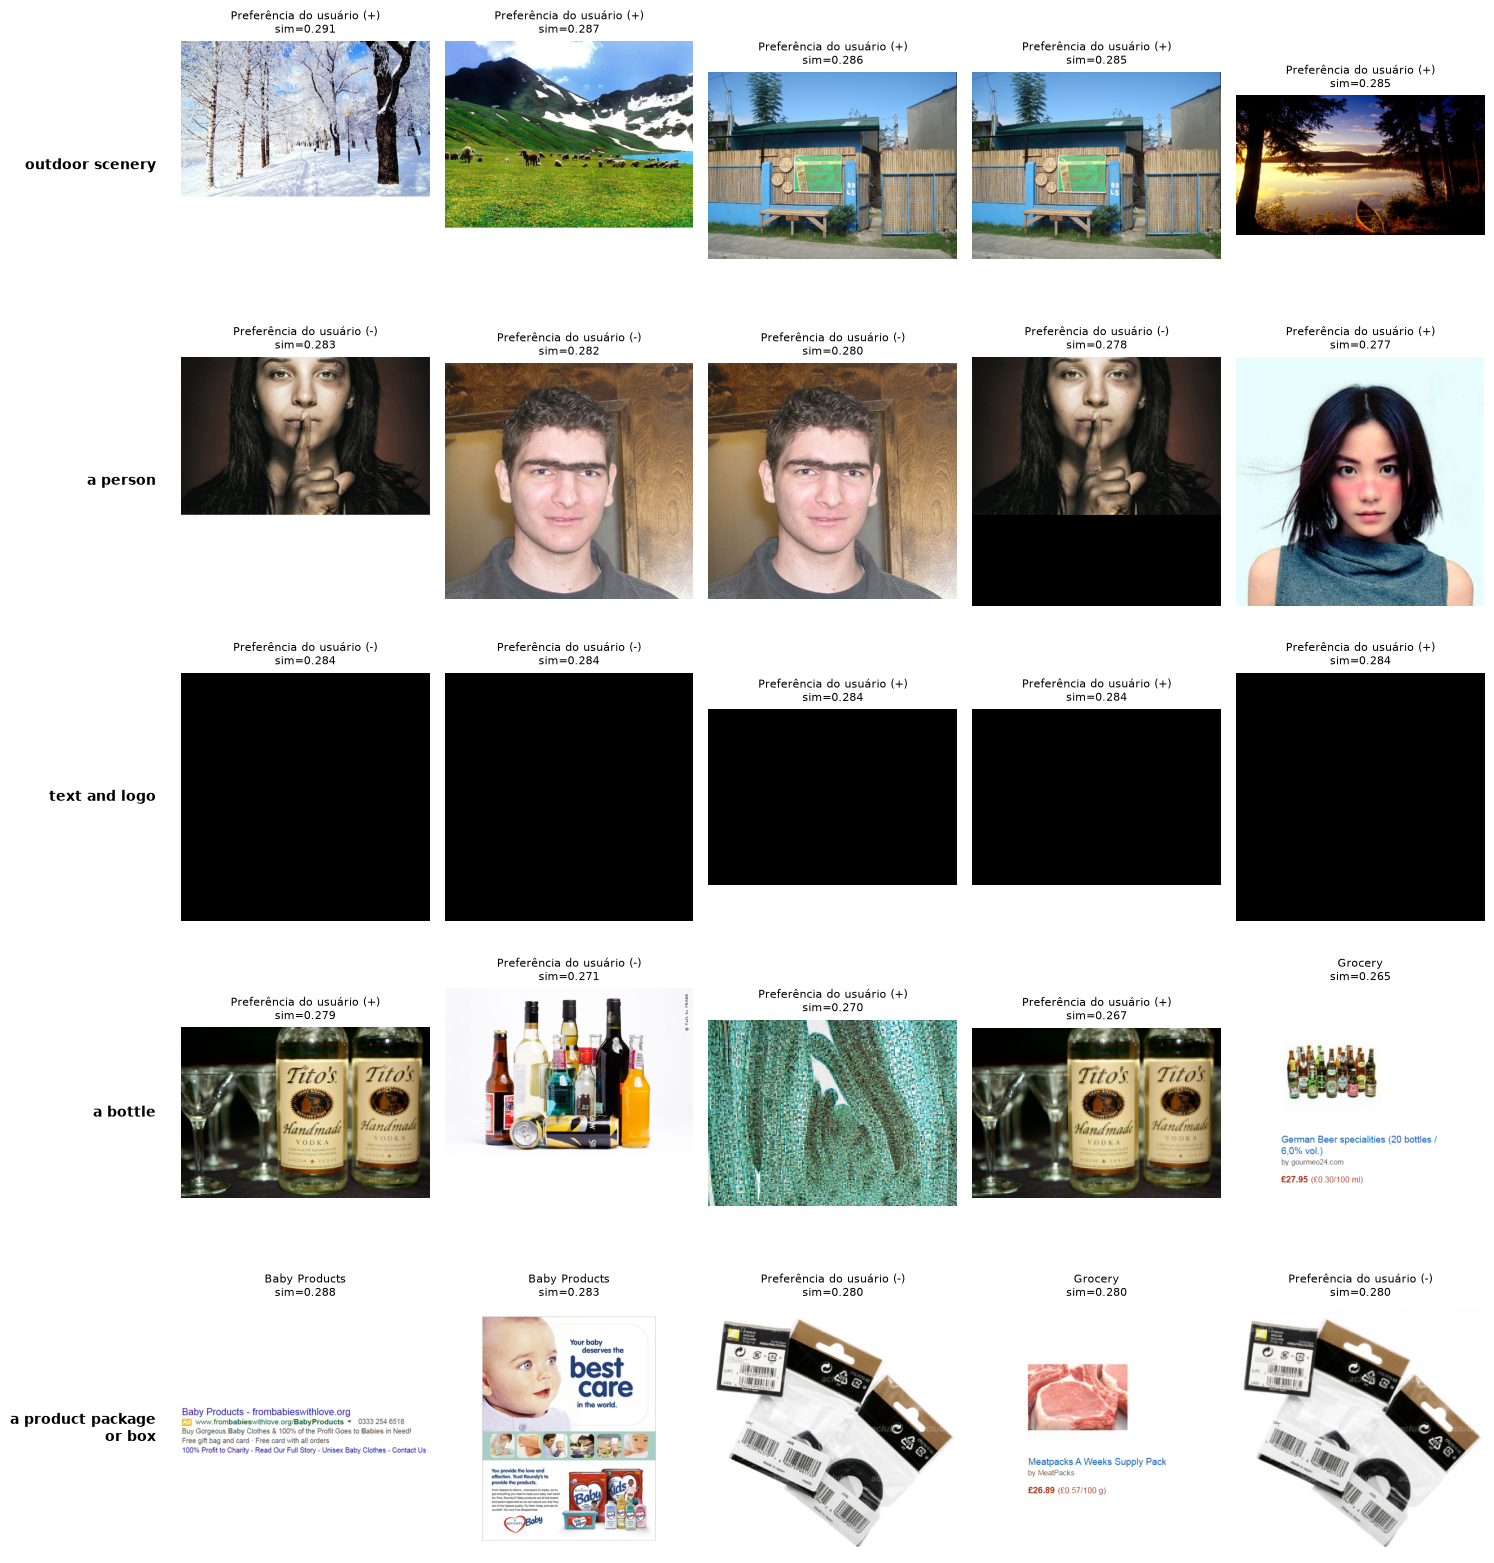

In [12]:
def show_grid(rows_of_idx, row_titles, scores=None, fname=None, n=5):
    fig, axes = plt.subplots(len(rows_of_idx), n, figsize=(3 * n, 3.2 * len(rows_of_idx)))
    axes = np.atleast_2d(axes)
    for r, (idxs, title) in enumerate(zip(rows_of_idx, row_titles)):
        for c in range(n):
            ax = axes[r, c]; ax.axis("off")
            if c < len(idxs):
                i = idxs[c]
                ax.imshow(Image.open(df.path.iloc[i]).convert("RGB"))
                sub = f"{df.category.iloc[i]}"
                if scores is not None:
                    sub += f"\nsim={scores[r][c]:.3f}"
                ax.set_title(sub, fontsize=8)
        axes[r, 0].text(-0.1, 0.5, title, transform=axes[r, 0].transAxes, ha="right", va="center",
                        fontsize=10, fontweight="bold", wrap=True)
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=110, bbox_inches="tight")
    plt.show()


top5 = ranking.conceito.head(5).tolist()
rows, scs = [], []
for c in top5:
    j = CONCEPTS.index(c)
    idx = np.argsort(-S[:, j])[:5]
    rows.append(idx); scs.append(S[idx, j])
show_grid(rows, top5, scs, FIG_DIR / "top5_conceitos.png")

### 3.3 Conceito × categoria de produto (validação quantitativa)

Restrito aos anúncios rotulados. Se o ranking for coerente, cada conceito concentra na categoria esperada
(*a car* → Automotive, *food* → Grocery, etc.). É a evidência quantitativa, não só visual.

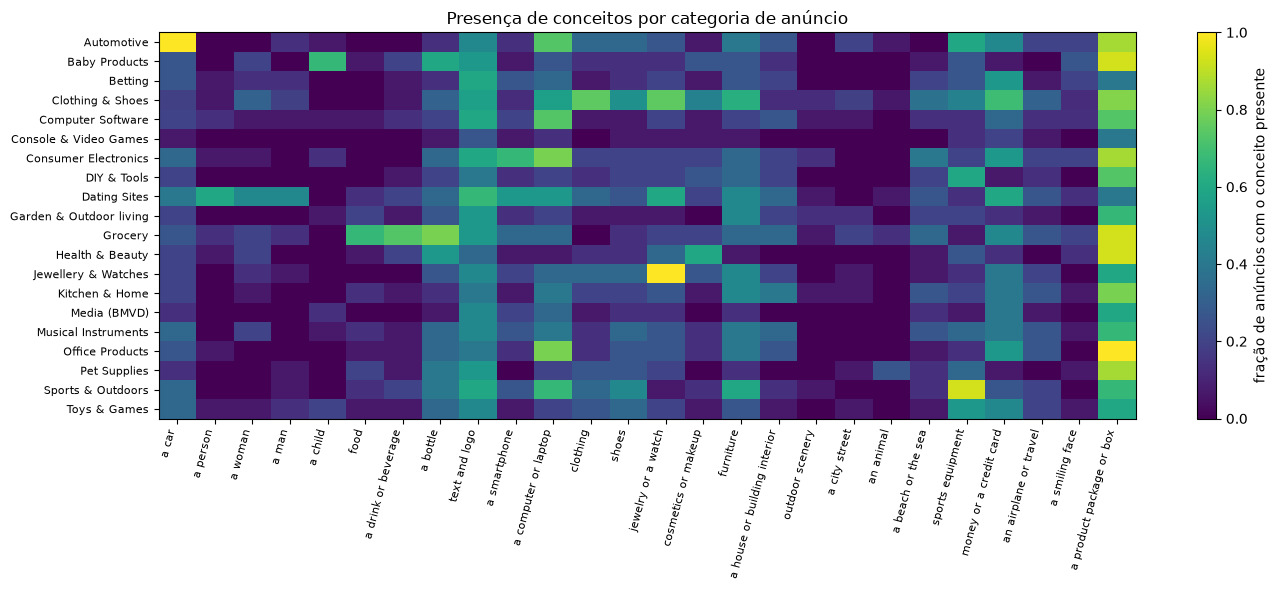

In [13]:
ct = (pd.DataFrame(present[ad_mask], columns=CONCEPTS)
      .assign(category=ad_cats.values).groupby("category").mean())
plt.figure(figsize=(14, 6))
plt.imshow(ct.values, aspect="auto", cmap="viridis")
plt.xticks(range(len(CONCEPTS)), CONCEPTS, rotation=75, ha="right", fontsize=8)
plt.yticks(range(len(ct)), ct.index, fontsize=8)
plt.colorbar(label="fração de anúncios com o conceito presente")
plt.title("Presença de conceitos por categoria de anúncio")
plt.tight_layout(); plt.savefig(FIG_DIR / "conceito_x_categoria.png", dpi=120); plt.show()

**Análise 2.1.** Com z-score por conceito (k=1), os conceitos mais frequentes são *outdoor scenery* (16,3%),
*a person* (16,3%), *text and logo* (16,1%), *a bottle* (15,5%) e *a product package or box* (15,3%). A cauda
dominada por cenários e pessoas reflete o peso das ~2,3 mil imagens de preferência dos usuários (fotos naturais) no
corpus; *a car* aparece só em 23º (13,5%), apesar de existir a categoria Automotive — sinal de que muitos anúncios de
carro são dominados por texto/marca, não pela foto do veículo inteiro.

**Conceitos pegajosos.** *text and logo* e *a product package or box* têm similaridade alta em quase todo anúncio; no
heatmap, a coluna *a product package or box* está acesa nas 20 categorias. Foi esse viés que o z-score por conceito
atenuou — a alternativa global os deixaria no topo por mérito artificial.

**Validação quantitativa (heatmap §3.3).** A diagonal esperada aparece com força: **Automotive × *a car* = 1,0**,
**Jewellery & Watches × *jewelry or a watch* ≈ 1,0**, **Sports & Outdoors × *sports equipment*** alto,
**Grocery × *food* / *a drink or beverage* / *a bottle*** alto, **Consumer Electronics / Computer Software ×
*a computer or laptop* / *a smartphone***, **Clothing & Shoes × *clothing* / *shoes***, **Baby Products × *a child***
e **Dating Sites × *a person* / *a man* / *a woman*** (anúncios de namoro mostram pessoas). O ranking é
semanticamente coerente — a concentração é medível, não só visual.

**Artefato observado.** O top-5 de *text and logo* (§3.2) é composto por **imagens totalmente pretas** (sim≈0,284):
há imagens em branco/pretas no conjunto de preferências, e o CLIP as aproxima do embedding de "text and logo".
É um efeito de qualidade de dados a registrar (não removidas para não alterar o corpus).

### 3.4 Comparação de modelos — ViT-B/32 vs. ViT-L/14 *(opcional, justifica a escolha)*

Reembeda o corpus com o ViT-L/14 e mede tempo e concordância dos rankings (Spearman). O L/14 é bem mais pesado
(sobretudo em CPU); a comparação mostra se o ganho justifica o custo na T4. **`RUN_L14 = False` por padrão** — ligar
na T4, onde também dá para medir a VRAM.

In [14]:
RUN_L14 = False  # True para rodar a comparação (pesada em CPU; ideal na T4)
if RUN_L14:
    from scipy.stats import spearmanr
    L_ID = "openai/clip-vit-large-patch14"
    model_l = CLIPModel.from_pretrained(
        L_ID, torch_dtype=torch.float16 if device == "cuda" else torch.float32
    ).to(device).eval()
    proc_l = CLIPProcessor.from_pretrained(L_ID)
    tok_l = CLIPTokenizer.from_pretrained(L_ID)

    @torch.no_grad()
    def embed_images_l(paths, bs=32):
        out = []
        for i in range(0, len(paths), bs):
            ims = [Image.open(p).convert("RGB") for p in paths[i:i + bs]]
            px = proc_l(images=ims, return_tensors="pt")["pixel_values"].to(device, model_l.dtype)
            e = model_l.get_image_features(pixel_values=px)
            out.append(torch.nn.functional.normalize(e.float(), dim=-1).cpu())
        return torch.cat(out)

    @torch.no_grad()
    def embed_texts_l(texts):
        tok = tok_l(texts, padding=True, return_tensors="pt").to(device)
        e = model_l.get_text_features(**tok)
        return torch.nn.functional.normalize(e.float(), dim=-1).cpu()

    t0 = time.time()
    img_emb_l = embed_images_l(df.path.tolist())
    t_l = time.time() - t0
    txt_l = torch.stack([
        torch.nn.functional.normalize(embed_texts_l([t.format(c) for t in TEMPLATES]).mean(0), dim=-1)
        for c in CONCEPTS
    ])
    S_l = (img_emb_l @ txt_l.T).numpy()
    freq_b = (S > (S.mean(0) + S.std(0))).sum(0)
    freq_l = (S_l > (S_l.mean(0) + S_l.std(0))).sum(0)
    rho, _ = spearmanr(freq_b, freq_l)
    print(f"ViT-L/14 embeddings em {t_l:.1f}s | Spearman(ranking B/32, L/14) = {rho:.3f}")
    del model_l
else:
    print("comparação L/14 pulada (RUN_L14=False)")

comparação L/14 pulada (RUN_L14=False)


## 4. (2.2) Busca semântica por consulta textual

**10 consultas** (≥8), variando de **genérico→específico** e de **concreto→abstrato**. Para cada uma, o top-5 por
cosine similarity contra o embedding da consulta.

In [15]:
QUERIES = [
    ("a car", "genérica", "concreta"),
    ("a red sports car on a road", "específica", "concreta"),
    ("a woman holding a perfume bottle", "específica", "concreta"),
    ("fast food", "genérica", "concreta"),
    ("a cold beer on a sunny day", "específica", "concreta"),
    ("luxury", "genérica", "abstrata"),
    ("freedom and adventure", "genérica", "abstrata"),
    ("a feeling of family happiness", "específica", "abstrata"),
    ("an ad targeted at young people", "específica", "abstrata"),
    ("technology that makes life easier", "específica", "abstrata"),
]
assert len(QUERIES) >= 8


def search(query, k=5):
    q = embed_texts([query])[0]
    sims = (img_emb @ q).numpy()
    idx = np.argsort(-sims)[:k]
    return idx, sims[idx]


results = []
for q, spec, abst in QUERIES:
    idx, sc = search(q)
    results.append((q, idx, sc))
    print(f"[{spec}/{abst}] {q!r}: categorias top-5 = {df.category.iloc[idx].tolist()}")

[genérica/concreta] 'a car': categorias top-5 = ['Preferência do usuário (+)', 'Preferência do usuário (+)', 'Preferência do usuário (-)', 'Preferência do usuário (+)', 'Preferência do usuário (+)']
[específica/concreta] 'a red sports car on a road': categorias top-5 = ['Preferência do usuário (+)', 'Preferência do usuário (+)', 'Preferência do usuário (+)', 'Preferência do usuário (-)', 'Preferência do usuário (-)']
[específica/concreta] 'a woman holding a perfume bottle': categorias top-5 = ['Preferência do usuário (+)', 'Preferência do usuário (+)', 'Preferência do usuário (+)', 'Preferência do usuário (+)', 'Preferência do usuário (-)']
[genérica/concreta] 'fast food': categorias top-5 = ['Preferência do usuário (-)', 'Preferência do usuário (-)', 'Preferência do usuário (-)', 'Preferência do usuário (-)', 'Preferência do usuário (-)']
[específica/concreta] 'a cold beer on a sunny day': categorias top-5 = ['Preferência do usuário (-)', 'Preferência do usuário (+)', 'Preferência do 

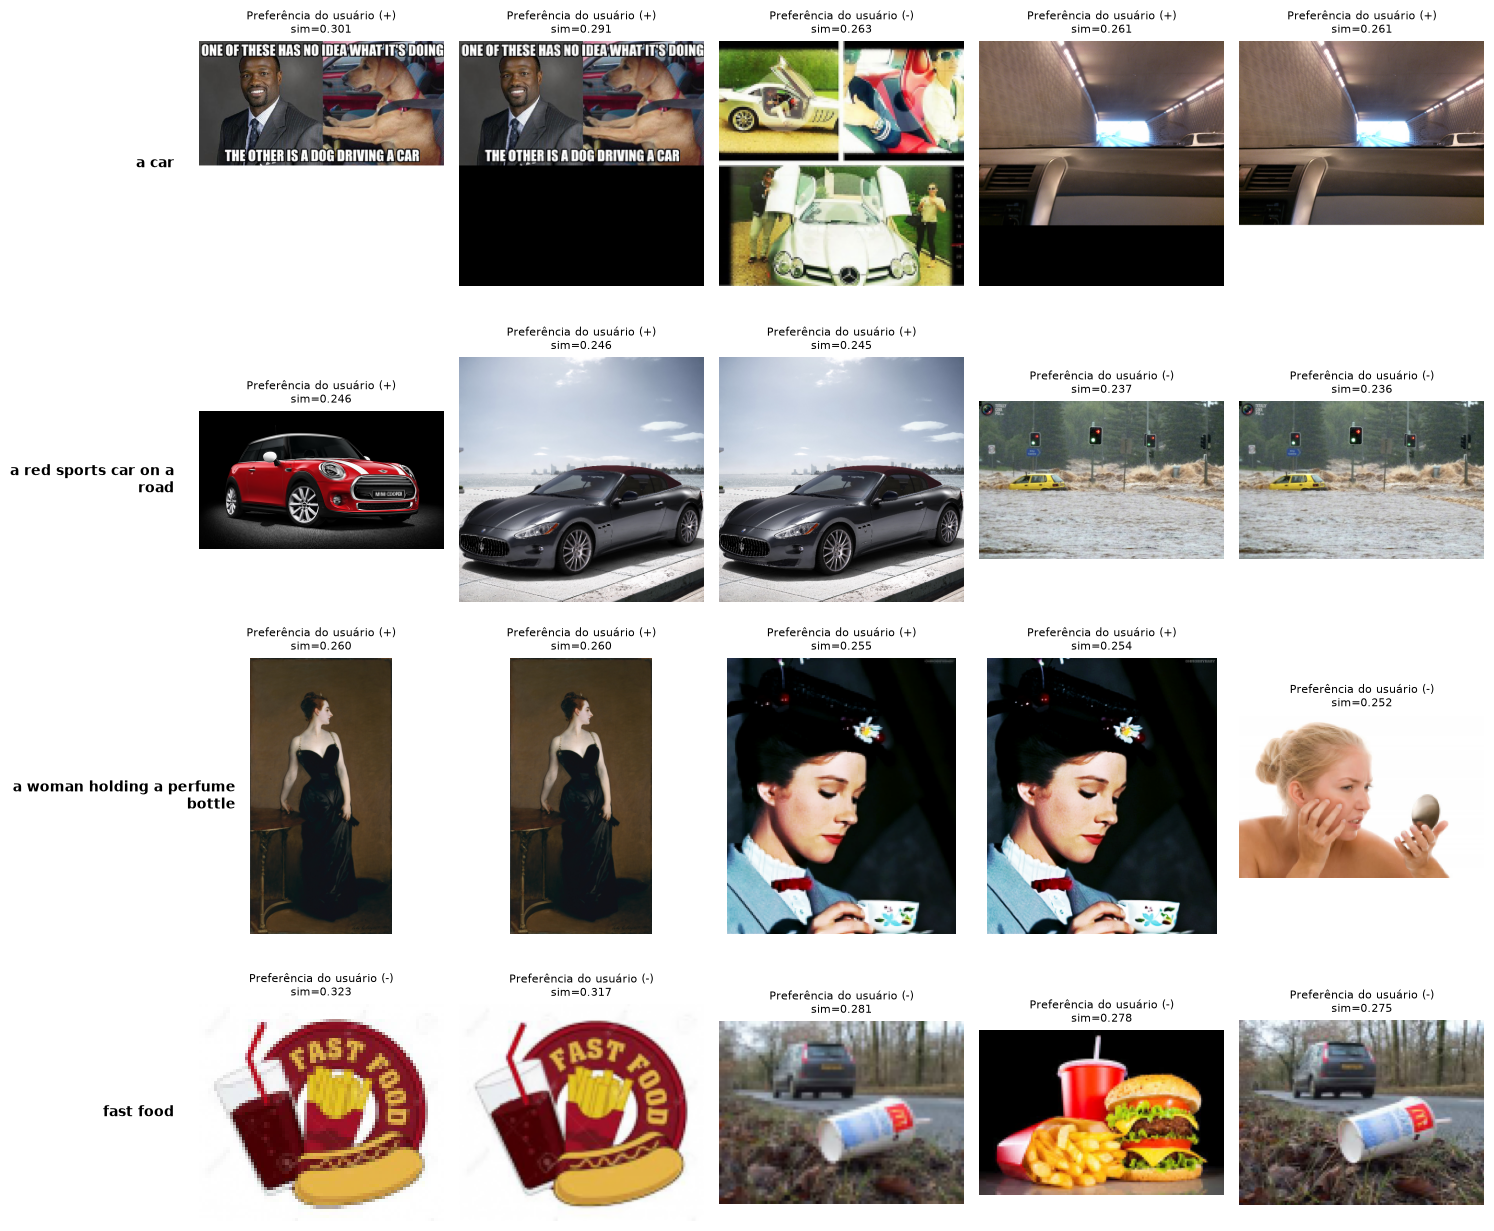

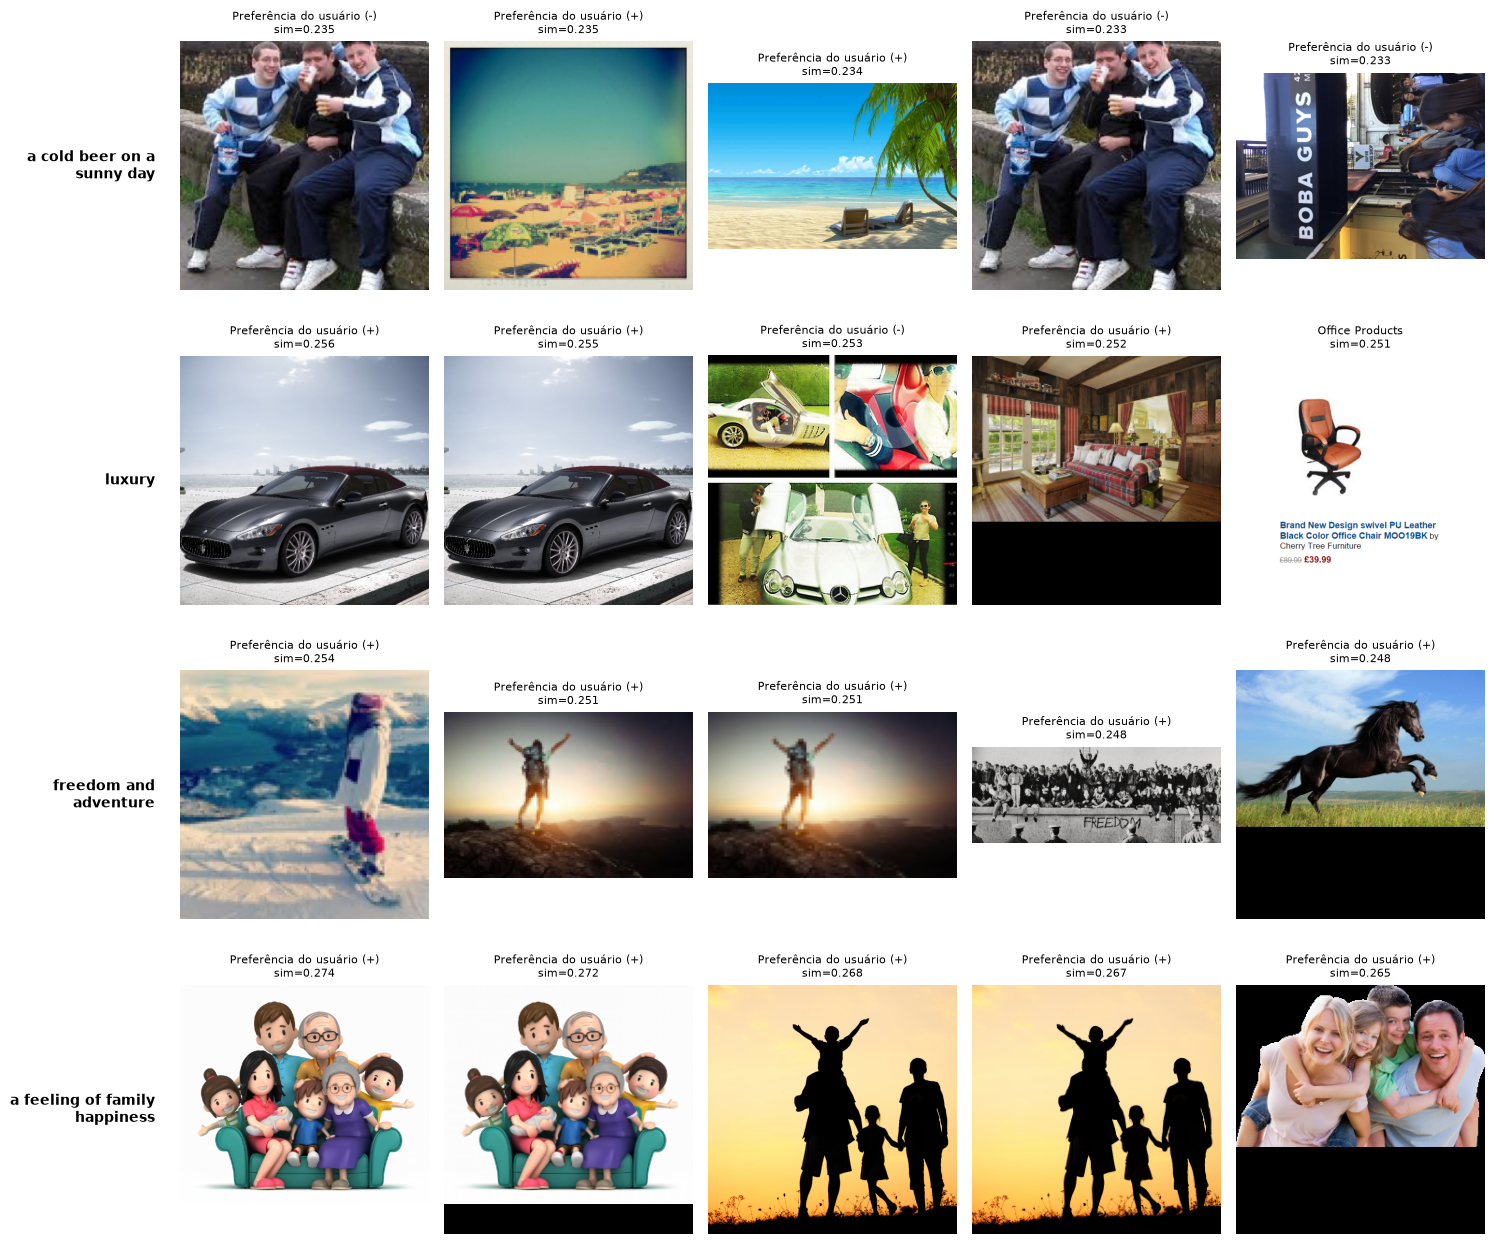

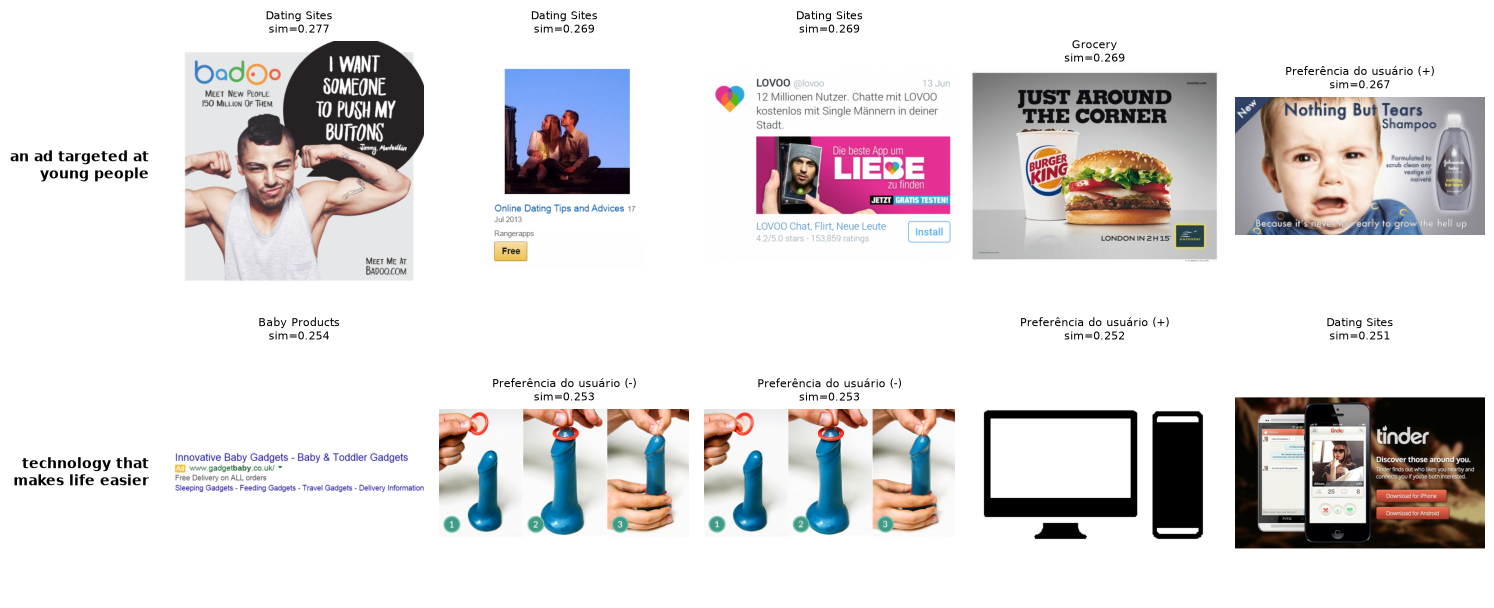

In [16]:
for i in range(0, len(results), 4):
    chunk = results[i:i + 4]
    show_grid([r[1] for r in chunk], [r[0] for r in chunk], [r[2] for r in chunk], FIG_DIR / f"busca_{i // 4 + 1}.png")

### 4.1 Análise por consulta

| # | Consulta | Tipo | Recuperou o esperado? | Interpretação inesperada / observações |
|---|---|---|---|---|
| 1 | a car | genérica/concreta | Parcial | top-1 é um **meme** com a palavra "CAR" no texto (*typographic*); #3–5 trazem carros reais (Mercedes, interior de carro) |
| 2 | a red sports car on a road | específica/concreta | Sim | Mini vermelho + Maserati esportivo; #4–5 = carro amarelo numa **enchente** (pegou a "road" alagada) |
| 3 | a woman holding a perfume bottle | específica/concreta | Parcial | pegou "mulher segurando algo" (quadro *Madame X*, Mary Poppins com xícara), não perfume; #5 mulher com espelho/maquiagem é o mais próximo |
| 4 | fast food | genérica/concreta | Sim | top-1/2 = **logo escrito "FAST FOOD"** (*typographic*); #4 = combo hambúrguer+fritas real |
| 5 | a cold beer on a sunny day | específica/concreta | Parcial | pegou "dia ensolarado" (praias) e pessoas bebendo, não cerveja gelada específica; #5 = placa "BOBA GUYS" |
| 6 | luxury | genérica/abstrata | Sim | carros de luxo (Maserati) + interior sofisticado; #5 (cadeira de escritório barata) é ruído |
| 7 | freedom and adventure | genérica/abstrata | Sim | pessoa no cume de braços abertos ao pôr do sol, snowboard, cavalo galopando; #4 = imagem com texto "FREEDOM" |
| 8 | a feeling of family happiness | específica/abstrata | Sim | famílias (cartoon, silhueta pai-filho ao pôr do sol, foto de família feliz) — muito coerente |
| 9 | an ad targeted at young people | específica/abstrata | Sim | Badoo, LOVOO, Tinder (**Dating Sites**) + Burger King — match pragmático (apps de namoro miram jovens) |
| 10 | technology that makes life easier | específica/abstrata | Parcial | pegou monitor+smartphone e Tinder (tech), mas também "baby gadgets" e um produto estranho (*typographic* "gadgets") |

**Padrões gerais.**
1. **As imagens de preferência dos usuários dominam o top-5** de quase toda consulta: fotos naturais casam melhor com
   descrições em linguagem natural do que os anúncios, densos em texto e grafismo. Os anúncios só vencem quando a
   consulta bate num nicho (Dating Sites em *"young people"*).
2. **Efeito typographic (*typographic attack*):** o CLIP frequentemente rankeia no topo imagens que contêm a
   *palavra* da consulta escrita ("CAR", "FAST FOOD", "FREEDOM"), não o objeto — o encoder aprendeu a ler texto na
   imagem durante o pré-treino contrastivo.
3. **Consultas abstratas** (*luxury*, *freedom and adventure*, *family happiness*) foram surpreendentemente bem
   recuperadas via imagens estereotipadas — o CLIP capturou associações culturais, não só objetos.
4. **Consultas específicas** (*perfume bottle*, *cold beer*) foram recuperadas parcialmente: o modelo acerta o núcleo
   ("mulher segurando", "dia ensolarado") e erra o detalhe.

## 5. Análises teóricas

### 5.1 Alinhamento visual-textual no CLIP

O CLIP tem **dois encoders** — um de imagem (ViT) e um de texto (Transformer) — que projetam suas saídas num
**espaço de embedding comum**. O treino é **contrastivo (InfoNCE simétrica)** sobre ~400M pares (imagem, legenda)
coletados da web: dentro de cada batch de N pares, a matriz N×N de similaridades imagem×texto deve ter os pares
corretos na **diagonal** (positivos) e todos os outros como **negativos**. A perda é simétrica — cross-entropy sobre
as linhas (imagem→texto) somada à das colunas (texto→imagem) — e a escala das similaridades é controlada por uma
**temperatura aprendível** (`logit_scale`).

Esse objetivo alinha semanticamente as duas modalidades: legendas parecidas caem perto das imagens que descrevem.
Por isso o CLIP faz **recuperação e classificação zero-shot sem treino supervisionado** — o "rótulo" deixa de ser
uma classe fixa e passa a ser **qualquer texto**. Para classificar/rankear, comparamos o embedding da imagem com o
embedding de uma frase (§2.1); para buscar, comparamos o embedding da consulta com os das imagens (§2.2). A
supervisão veio, de forma fraca, da linguagem natural das legendas — não de anotações manuais deste corpus. É também
o que explica o *typographic attack* visto em §4.1: como o modelo aprendeu a associar texto escrito à sua transcrição,
a palavra dentro da imagem entra no mesmo espaço da consulta.

### 5.2 Consulta textual no CLIP vs. tokenização no BERT — padding e attention mask

| | **CLIP (text encoder)** | **BERT** |
|---|---|---|
| Tokenizador | **BPE** (byte-pair encoding) | **WordPiece** |
| Tokens especiais | `<|startoftext|>` / `<|endoftext|>` (EOT) | `[CLS]` / `[SEP]` |
| Contexto máximo | **77 tokens** | 512 tokens |
| Atenção | **causal** (máscara triangular) + máscara de padding | **bidirecional** + máscara de padding |
| Representação da frase | estado do token **EOT** | estado do token **[CLS]** |

O **padding** iguala o comprimento das sequências dentro de um batch (necessário para empilhar tensores). A
**attention mask** marca quais posições são tokens reais (1) e quais são padding (0), impedindo que os tokens reais
"atendam" ao padding. Sem a máscara, o embedding da frase poderia depender de quanto padding foi adicionado.

A demonstração abaixo mostra os `input_ids`/`attention_mask` dos dois tokenizadores e o efeito de **remover a
máscara** no embedding do CLIP.

In [17]:
from transformers import BertTokenizer
bert_tok = BertTokenizer.from_pretrained("bert-base-uncased")
qs = ["a car", "a feeling of family happiness at the beach"]

c = tokenizer(qs, padding=True, return_tensors="pt")
b = bert_tok(qs, padding=True, return_tensors="pt")
for name, tok, enc in [("CLIP", tokenizer, c), ("BERT", bert_tok, b)]:
    print(f"--- {name} ---")
    for i in range(len(qs)):
        print(" tokens:", tok.convert_ids_to_tokens(enc["input_ids"][i]))
        print(" attention_mask:", enc["attention_mask"][i].tolist())

--- CLIP ---
 tokens: ['<|startoftext|>', 'a</w>', 'car</w>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>']
 attention_mask: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
 tokens: ['<|startoftext|>', 'a</w>', 'feeling</w>', 'of</w>', 'family</w>', 'happiness</w>', 'at</w>', 'the</w>', 'beach</w>', '<|endoftext|>']
 attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
--- BERT ---
 tokens: ['[CLS]', 'a', 'car', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
 attention_mask: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
 tokens: ['[CLS]', 'a', 'feeling', 'of', 'family', 'happiness', 'at', 'the', 'beach', '[SEP]']
 attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


C:\Users\ggsan\Documents\Projetos\dl-computer-vision-pd\A2_clip_ads16\venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [18]:
# Efeito da attention mask: mesma consulta com e sem a máscara de padding (CLIP)
with torch.no_grad():
    enc = tokenizer(qs, padding="max_length", max_length=77, return_tensors="pt").to(device)
    with_mask = torch.nn.functional.normalize(model.get_text_features(**enc).float(), dim=-1)
    no_mask = torch.nn.functional.normalize(
        model.get_text_features(input_ids=enc["input_ids"]).float(), dim=-1)
print("cos(com máscara, sem máscara) por consulta:", (with_mask * no_mask).sum(-1).tolist())
# No CLIP, a atenção causal + pooling no token EOT tornam o padding à direita quase inofensivo (cosseno ~1).
# No BERT (bidirecional, pooling em [CLS]), remover a máscara contaminaria o [CLS] com os tokens [PAD].

cos(com máscara, sem máscara) por consulta: [0.9999998807907104, 1.0000001192092896]


**Observação da demonstração.** O CLIP preenche à direita repetindo `<|endoftext|>` e a máscara zera essas
posições; o BERT usa `[PAD]` após `[SEP]`. Medido acima, `cos(com máscara, sem máscara) ≈ 1,0` no CLIP: a atenção
**causal** somada ao *pooling* no token **EOT** (que vem antes do padding) torna o padding à direita quase inofensivo.
No BERT seria diferente — atenção **bidirecional** e *pooling* no `[CLS]` fazem o `[CLS]` "ver" todas as posições, então
sem a máscara ele seria contaminado pelos `[PAD]`.

## 6. Conclusões e limitações

O CLIP pré-treinado extrai estrutura semântica do ADS-16 **sem nenhum treino**: o ranking por z-score alinha
conceitos às categorias de produto esperadas (Automotive × *a car* = 1,0; Jewellery × *jewelry* ≈ 1,0;
Sports × *sports equipment*; Grocery × *food*), e a busca em linguagem natural recupera o conteúdo pedido — incluindo
consultas abstratas (*luxury*, *freedom and adventure*, *family happiness*).

**Limitações observadas (casos concretos):**
- **Typographic attack:** o modelo rankeia no topo imagens com a *palavra* escrita (meme com "CAR", logo "FAST FOOD",
  texto "FREEDOM") em vez do objeto — o encoder lê texto na imagem.
- **Conceitos pegajosos:** *text and logo* e *a product package or box* aparecem em quase todo anúncio; exigiram o
  threshold por conceito (z-score) para não distorcer o ranking.
- **Qualidade de dados:** imagens totalmente pretas no conjunto de preferências poluem o conceito *text and logo*.
- **Domínio publicitário diluído:** com o corpus completo, as fotos pessoais dos usuários dominam a busca; os anúncios
  curados só emergem em nichos. Restringir a busca aos 301 anúncios rotulados seria o próximo passo para focar em
  publicidade.
- **Detalhe fino:** consultas específicas (*perfume bottle*, *cold beer*) recuperam o núcleo semântico mas erram o
  detalhe.

**O que mudaria:** rodar a busca separadamente sobre anúncios e sobre imagens de preferência; filtrar imagens
degeneradas (pretas/constantes); e usar o ViT-L/14 (§3.4) onde a precisão fina importa.

## Uso de IA

Ferramentas de IA utilizadas para auxílio neste notebook

Todo o código foi executado e validado pelo autor; as análises e conclusões foram verificadas contra os resultados
reais obtidos.